## Import the importance laibary

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

# Read and discribe the data

In [ ]:
df = pd.read_csv('/content/Complete_Dataset_updated(in).csv')
df

,Date,DOY,Sample,Sub-Sample,Lat,Long_,Sample_type,Animals,DM,MM,...,PRES_ATM,HUM_REL,TP_SFC_AVG,Wind_Dir,Dew_Point,Radiative_Dif_AVG,Radiative_Direct_AVG,PPFD,Longwave_Rad_AVG,Environmental Suitability Index
0,7/6/2022,187,1,1,-20.446717,-54.839505,Q1,1,54.177195,6.869019,...,1014.941667,47.458333,23.187826,119.917171,8.584028,160.617416,7.444173,358.837504,344.212487,3.209516
1,7/6/2022,187,1,2,-20.446717,-54.839505,Q1,1,54.177058,6.835684,...,1014.941667,47.458333,23.187826,119.917171,8.584028,160.617416,7.444173,358.837504,344.212487,5.109516
2,7/6/2022,187,2,1,-20.446996,-54.838856,Q4,1,52.260843,5.125652,...,1014.941667,47.458333,23.187826,119.917171,8.584028,160.617416,7.444173,358.837504,344.212487,3.506646
3,7/6/2022,187,2,2,-20.446996,-54.838856,Q4,1,52.285797,5.241126,...,1014.941667,47.458333,23.187826,119.917171,8.584028,160.617416,7.444173,358.837504,344.212487,4.606646
4,7/6/2022,187,3,1,-20.446424,-54.839246,G2,1,49.984466,4.742429,...,1014.941667,47.458333,23.187826,119.917171,8.584028,160.617416,7.444173,358.837504,344.212487,3.703806
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307,3/1/2023,60,154,2,-20.446365,-54.838516,Q4,1,31.915926,10.798575,...,1015.800000,75.291667,19.443586,124.981135,12.442361,70.217280,296.533237,593.233703,400.042911,5.312839
308,3/1/2023,60,155,1,-20.446937,-54.839311,S1,0,45.505167,8.263333,...,1015.800000,75.291667,19.443586,124.981135,12.442361,70.217280,296.533237,593.233703,400.042911,4.237497
309,3/1/2023,60,155,2,-20.446937,-54.839311,S1,0,45.493257,8.218142,...,1015.800000,75.291667,19.443586,124.981135,12.442361,70.217280,296.533237,593.233703,400.042911,5.537497
310,3/1/2023,60,156,1,-20.446972,-54.839168,S2,0,43.740695,8.313133,...,1015.800000,75.291667,19.443586,124.981135,12.442361,70.217280,296.533237,593.233703,400.042911,4.834511


In [ ]:
columns = [
    'Biomass', 'DM', 'TEMP_MAX', 'TEMP_MIN', 'Rainfall', 'RAD_SOL', 'WIND_SPD',
    'HUM_REL', 'PPFD', 'NDVI', 'EVI', 'LAI', 'SAVI']
df1=df[columns]

In [ ]:
df1.describe()

,Biomass,DM,TEMP_MAX,TEMP_MIN,Rainfall,RAD_SOL,WIND_SPD,HUM_REL,PPFD,NDVI,EVI,LAI,SAVI
count,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000
mean,4302.398077,38.154921,31.096795,20.689744,1.291026,21.283462,14.955769,58.668803,496.995825,0.299255,0.231251,0.718667,0.448843
std,3279.988726,11.608339,1.990796,2.565168,3.564461,4.661218,3.792703,12.934797,190.600428,0.105571,0.087852,0.317849,0.158342
min,305.866667,16.935654,26.600000,14.600000,0.000000,10.940000,7.000000,30.291667,216.264717,-0.003776,-0.002823,-0.128212,-0.005664
25%,2026.333333,29.645366,30.400000,18.300000,0.000000,17.630000,12.400000,48.958333,358.950201,0.212842,0.153675,0.437998,0.319231
50%,3189.833333,35.102975,31.300000,21.200000,0.000000,21.685000,14.500000,58.229167,522.804713,0.303419,0.239205,0.747444,0.455091
75%,5237.250000,48.707920,32.000000,22.700000,0.800000,24.220000,16.825000,69.166667,587.925182,0.382373,0.295375,0.950667,0.573504
max,15634.666670,66.492922,35.100000,25.700000,18.400000,30.240000,22.100000,77.041667,1161.230217,0.496181,0.401599,1.334983,0.744206


In [ ]:
correlation_matrix=df1.corr()

In [ ]:
correlation_matrix['Biomass'].sort_values(ascending=False)

,Biomass
Biomass,1.000000
NDVI,0.362917
SAVI,0.362915
EVI,0.350721
LAI,0.350721
HUM_REL,0.157437
DM,0.100397
Rainfall,0.093036
WIND_SPD,-0.043760
TEMP_MIN,-0.045420


In [ ]:
df1.value_counts(normalize=True).head(10)

Biomass      DM         TEMP_MAX  TEMP_MIN  Rainfall  RAD_SOL  WIND_SPD  HUM_REL    PPFD        NDVI      EVI       LAI       SAVI    
305.866667   50.040418  30.7      19.2      0.0       16.17    21.8      47.458333  358.837504  0.212842  0.150619  0.426941  0.319231    0.003205
4217.000000  26.721031  31.8      22.7      0.0       17.25    14.5      55.708333  334.032217  0.483904  0.393598  1.306036  0.725794    0.003205
4442.333333  36.634411  30.6      20.1      0.0       14.50    18.4      48.958333  216.264717  0.333453  0.255843  0.807639  0.500134    0.003205
4370.333333  30.845800  31.8      22.7      0.0       17.25    14.5      55.708333  334.032217  0.428673  0.336444  1.099255  0.642953    0.003205
             30.818067  31.8      22.7      0.0       17.25    14.5      55.708333  334.032217  0.428673  0.336444  1.099255  0.642953    0.003205
4294.000000  30.056837  27.8      17.1      0.0       21.86    11.3      58.541667  522.804713  0.438464  0.343935  1.126356  0.657637    0.003205
             30.026943  27.8      17.1      0.0       21.86    11.3      58.541667  522.804713  0.438464  0.343935  1.126356  0.657637    0.003205
4278.666667  34.659170  29.9      18.3      0.0       17.63    11.8      65.166667  419.644953  0.349739  0.263400  0.834982  0.524560    0.003205
             34.575637  29.9      18.3      0.0       17.63    11.8      65.166667  419.644953  0.349739  0.263400  0.834982  0.524560    0.003205
4217.000000  26.637364  31.8      22.7      0.0       17.25    14.5      55.708333  334.032217  0.483904  0.393598  1.306036  0.725794    0.003205
Name: proportion, dtype: float64

#Descriptive Statistics


In [ ]:

central_tendency = {
    "Mean": df1.mean(),
    "Median": df1.median(),
    "Mode": df1.mode().iloc[0]
}
dispersion = {
    "Range": df1.max() - df1.min(),
    "Variance": df1.var(),
    "Standard Deviation": df1.std()
}
percentiles = {
    "25th Percentile": df1.quantile(0.25),
    "Median (50th Percentile)": df1.quantile(0.5),
    "75th Percentile": df1.quantile(0.75)
}

Q1 = df1.quantile(0.25)
Q3 = df1.quantile(0.75)
IQR = Q3 - Q1
outliers = ((df1 < (Q1 - 1.5 * IQR)) | (df1 > (Q3 + 1.5 * IQR))).sum()

print("\nCentral Tendency:\n", pd.DataFrame(central_tendency))
print("\nDispersion:\n", pd.DataFrame(dispersion))
print("\nPercentiles:\n", pd.DataFrame(percentiles))
print("\nOutliers Detected:\n", outliers)



Central Tendency:
                  Mean       Median        Mode
Biomass   4302.398077  3189.833333  414.333333
DM          38.154921    35.102975   16.935654
TEMP_MAX    31.096795    31.300000   31.800000
TEMP_MIN    20.689744    21.200000   21.200000
Rainfall     1.291026     0.000000    0.000000
RAD_SOL     21.283462    21.685000   17.630000
WIND_SPD    14.955769    14.500000   12.400000
HUM_REL     58.668803    58.229167   55.708333
PPFD       496.995825   522.804713  334.032217
NDVI         0.299255     0.303419    0.147367
EVI          0.231251     0.239205    0.111223
LAI          0.718667     0.747444    0.284406
SAVI         0.448843     0.455091    0.221031

Dispersion:
                  Range      Variance  Standard Deviation
Biomass   15328.800003  1.075833e+07         3279.988726
DM           49.557268  1.347535e+02           11.608339
TEMP_MAX      8.500000  3.963269e+00            1.990796
TEMP_MIN     11.100000  6.580087e+00            2.565168
Rainfall     18.400000 

# Relationships Between Features


In [ ]:
import pandas as pd

df1 = df1.copy()
df1['DM_Category'] = pd.cut(df1['DM'], bins=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

df1['Biomass_Category'] = pd.cut(df1['Biomass'], bins=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

contingency_table = pd.crosstab(
    index=df1['DM_Category'],
    columns=df1['Biomass_Category'],
    margins=True,
    normalize='index'
)

contingency_table.index.name = 'DM_Category'
contingency_table.columns.name = 'Biomass_Category'
print("Contingency Table:\n", contingency_table)


Contingency Table:
 Biomass_Category  Very Low       Low    Medium      High  Very High
DM_Category                                                        
Very Low          0.590909  0.409091  0.000000  0.000000   0.000000
Low               0.604651  0.286822  0.031008  0.046512   0.031008
Medium            0.327273  0.236364  0.109091  0.181818   0.145455
High              0.517241  0.310345  0.068966  0.068966   0.034483
Very High         0.538462  0.307692  0.153846  0.000000   0.000000
All               0.532051  0.301282  0.057692  0.064103   0.044872


In [ ]:
sns.set(style="whitegrid")



# Visualizations

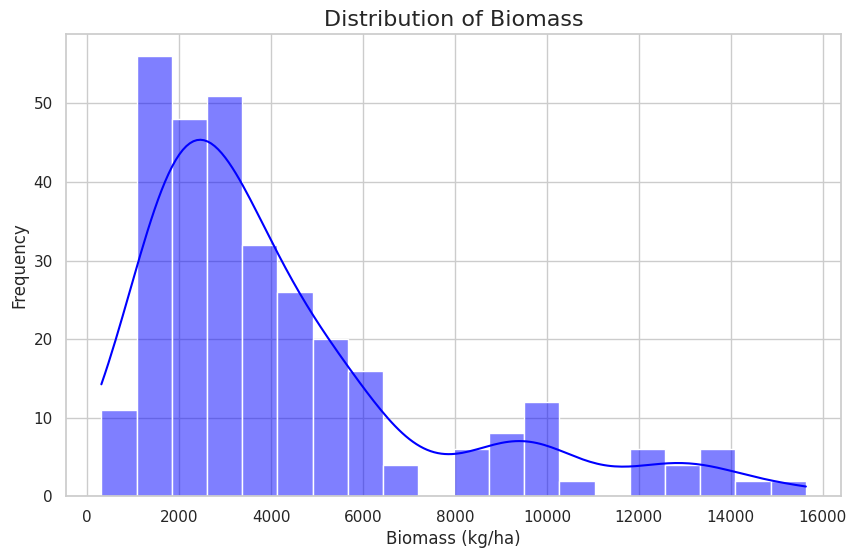

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df1['Biomass'], bins=20, kde=True, color='blue')
plt.title('Distribution of Biomass', fontsize=16)
plt.xlabel('Biomass (kg/ha)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()



<ipython-input-13-d796148e259c>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='DM_Category', y='Biomass', data=df1, palette='Set2')


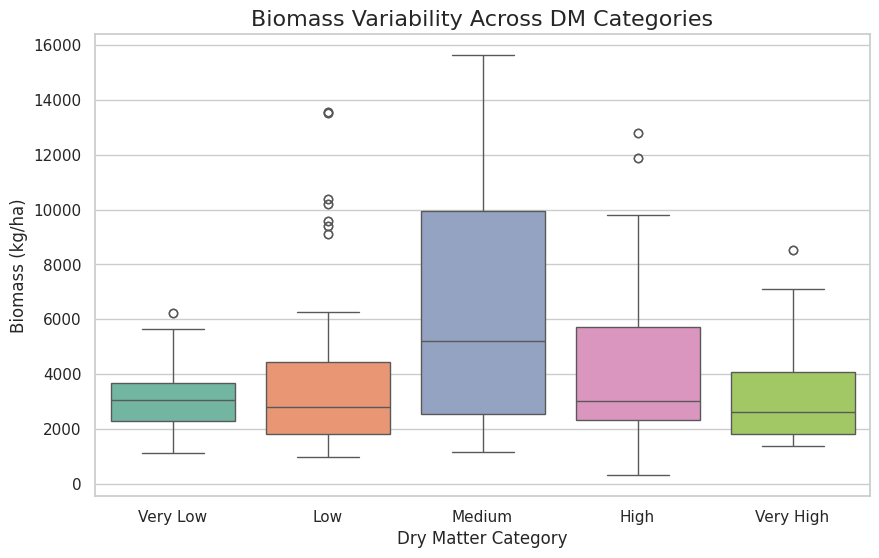

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='DM_Category', y='Biomass', data=df1, palette='Set2')
plt.title('Biomass Variability Across DM Categories', fontsize=16)
plt.xlabel('Dry Matter Category', fontsize=12)
plt.ylabel('Biomass (kg/ha)', fontsize=12)
plt.show()

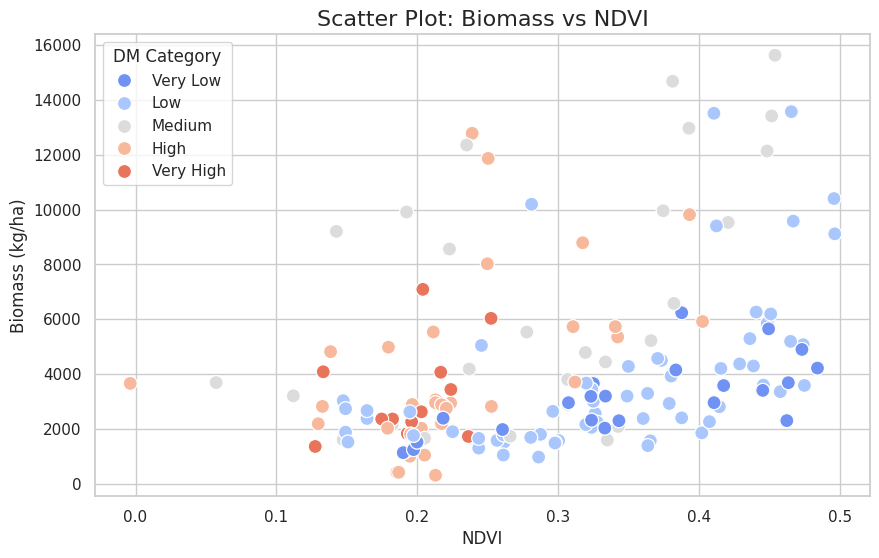

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='NDVI', y='Biomass', data=df1, hue='DM_Category', palette='coolwarm', s=100)
plt.title('Scatter Plot: Biomass vs NDVI', fontsize=16)
plt.xlabel('NDVI', fontsize=12)
plt.ylabel('Biomass (kg/ha)', fontsize=12)
plt.legend(title='DM Category')
plt.show()

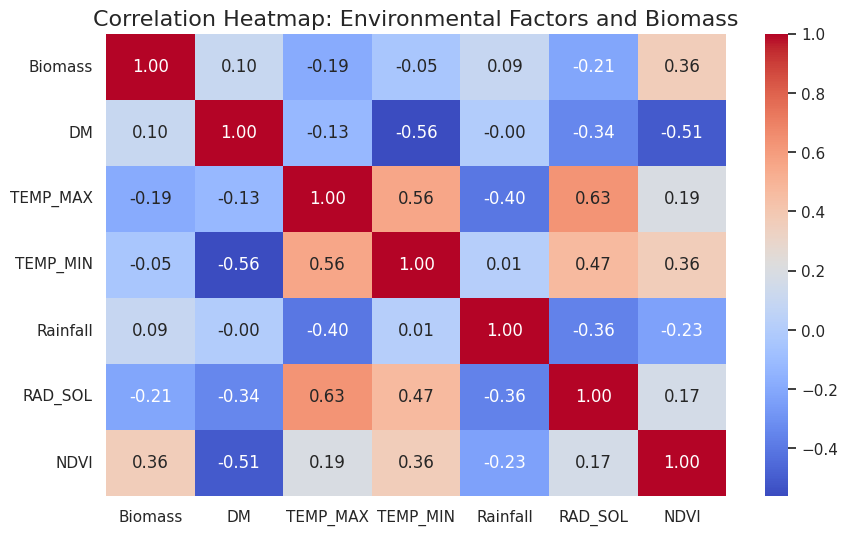

In [ ]:
correlation_data = df1[['Biomass', 'DM', 'TEMP_MAX', 'TEMP_MIN', 'Rainfall', 'RAD_SOL', 'NDVI']].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_data, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap: Environmental Factors and Biomass', fontsize=16)
plt.show()

In [ ]:
X = df1[['DM', 'TEMP_MAX', 'TEMP_MIN', 'Rainfall', 'RAD_SOL', 'NDVI', 'EVI', 'LAI', 'SAVI']]
y = df1['Biomass']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Selection Techniques

In [ ]:
k_best_selector = SelectKBest(score_func=f_regression, k=5)
k_best_selector.fit(X_train, y_train)
k_best_scores = k_best_selector.scores_

In [ ]:
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
feature_importances = rf_model.feature_importances_

In [ ]:
feature_selection_results = pd.DataFrame({
    'Feature': X.columns,
    'KBest_Scores': k_best_scores,
    'RandomForest_Importance': feature_importances
}).sort_values(by='KBest_Scores', ascending=False)

print("Feature Selection Results:\n", feature_selection_results)

Feature Selection Results:
     Feature  KBest_Scores  RandomForest_Importance
5      NDVI     32.523669                 0.118268
8      SAVI     32.523356                 0.119173
6       EVI     30.782985                 0.115484
7       LAI     30.782985                 0.135367
1  TEMP_MAX     12.620421                 0.060674
4   RAD_SOL      9.804170                 0.046916
0        DM      2.347470                 0.340175
3  Rainfall      2.287580                 0.019416
2  TEMP_MIN      0.549296                 0.044526


# Forecasting Models

# Exponential Smoothing

In [ ]:
time_series_model = ExponentialSmoothing(df1['Biomass'], trend='add', seasonal=None, seasonal_periods=None)
time_series_fit = time_series_model.fit()
time_series_forecast = time_series_fit.fittedvalues
time_series_mse = mean_squared_error(df1['Biomass'], time_series_forecast)
time_series_rmse = np.sqrt(time_series_mse)
print("RMSE: ", time_series_rmse)

RMSE:  2589.8194341292965


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


# Linear Regression

In [ ]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_predictions = linear_model.predict(X_test)
linear_mse = mean_squared_error(y_test, linear_predictions)
linear_rmse = np.sqrt(linear_mse)
print("RMSE: ", linear_rmse)

RMSE:  2918.552234894588


# Decision Tree Regression

In [ ]:
decision_tree_model = DecisionTreeRegressor(random_state=42)
decision_tree_model.fit(X_train, y_train)
decision_tree_predictions = decision_tree_model.predict(X_test)
decision_tree_mse = mean_squared_error(y_test, decision_tree_predictions)
decision_tree_rmse = np.sqrt(decision_tree_mse)
print("RMSE: ", decision_tree_rmse)

RMSE:  1359.2364540772408


# LSTM

In [ ]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df1[['Biomass']])

In [ ]:
sequence_length = 3
X_lstm = []
y_lstm = []
for i in range(len(scaled_data) - sequence_length):
    X_lstm.append(scaled_data[i:i + sequence_length])
    y_lstm.append(scaled_data[i + sequence_length])

X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)

In [ ]:
split_index = int(len(X_lstm) * 0.8)
X_train_lstm, X_test_lstm = X_lstm[:split_index], X_lstm[split_index:]
y_train_lstm, y_test_lstm = y_lstm[:split_index], y_lstm[split_index:]

In [ ]:
lstm_model = Sequential([
    LSTM(50, activation='relu', input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
lstm_model.fit(X_train_lstm, y_train_lstm, epochs=50, batch_size=1, verbose=1)

Epoch 1/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0679
Epoch 2/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0346
Epoch 3/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0318
Epoch 4/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0250
Epoch 5/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0216
Epoch 6/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0260
Epoch 7/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0245
Epoch 8/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0273
Epoch 9/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0254
Epoch 10/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0239
Epoch 11/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0239
Epoch 12/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0283
Epoch 13/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0225
Epoch 14/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0207
Epoch 15/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

In [ ]:
lstm_predictions = lstm_model.predict(X_test_lstm)
lstm_mse = mean_squared_error(y_test_lstm, lstm_predictions)

# Display the LSTM results
print(f"LSTM Model Mean Squared Error: {lstm_mse}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
LSTM Model Mean Squared Error: 0.032207799705949836


# Compare the Effectiveness

In [ ]:
time_series_mae = mean_absolute_error(df1['Biomass'], time_series_forecast)
time_series_r2 = r2_score(df1['Biomass'], time_series_forecast)

In [ ]:
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_r2 = r2_score(y_test, linear_predictions)

In [ ]:
decision_tree_mae = mean_absolute_error(y_test, decision_tree_predictions)
decision_tree_r2 = r2_score(y_test, decision_tree_predictions)

In [ ]:
lstm_mae = mean_absolute_error(y_test_lstm, lstm_predictions)
lstm_r2 = r2_score(y_test_lstm, lstm_predictions)

In [ ]:
model_comparison = pd.DataFrame({
    'Model': ['Exponential Smoothing', 'Linear Regression', 'Decision Tree Regression', 'LSTM'],
    'Mean Absolute Error (MAE)': [time_series_mae, linear_mae, decision_tree_mae, lstm_mae],
    'R-Squared (R²)': [time_series_r2, linear_r2, decision_tree_r2, lstm_r2]
})

print(model_comparison.sort_values(by='R-Squared (R²)'))

                      Model  Mean Absolute Error (MAE)  R-Squared (R²)
1         Linear Regression                2144.578887        0.327161
0     Exponential Smoothing                1231.274049        0.374556
3                      LSTM                   0.102348        0.476530
2  Decision Tree Regression                 578.155556        0.854063


# visualizations

In [ ]:
models = ['Exponential Smoothing', 'Linear Regression', 'Decision Tree Regression', 'LSTM']
mae_values = [time_series_mae, linear_mae, decision_tree_mae, lstm_mae]
r2_values = [time_series_r2, linear_r2, decision_tree_r2, lstm_r2]

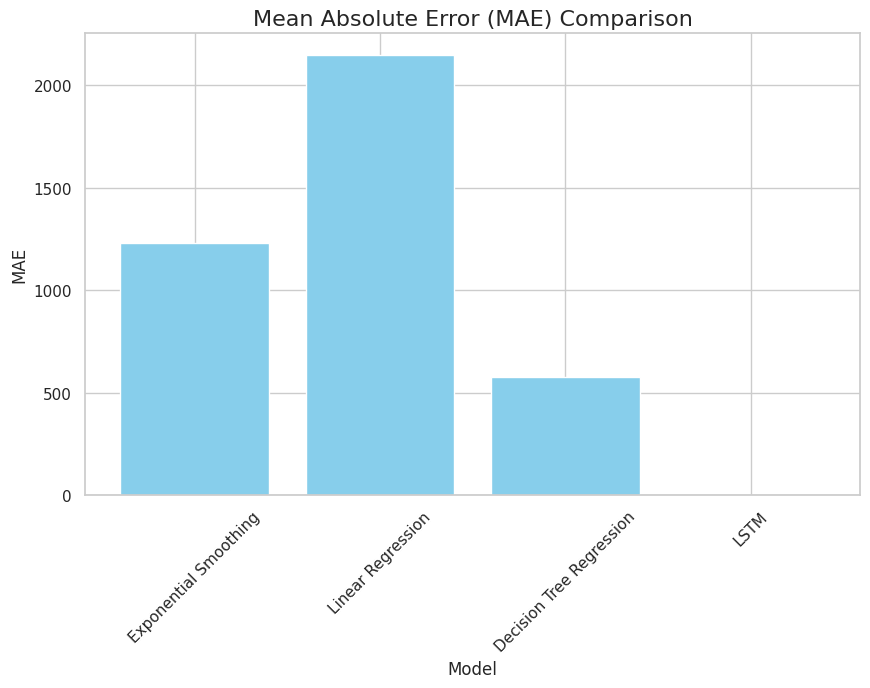

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(models, mae_values, color='skyblue')
plt.title('Mean Absolute Error (MAE) Comparison', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('MAE', fontsize=12)
plt.xticks(rotation=45)
plt.show()

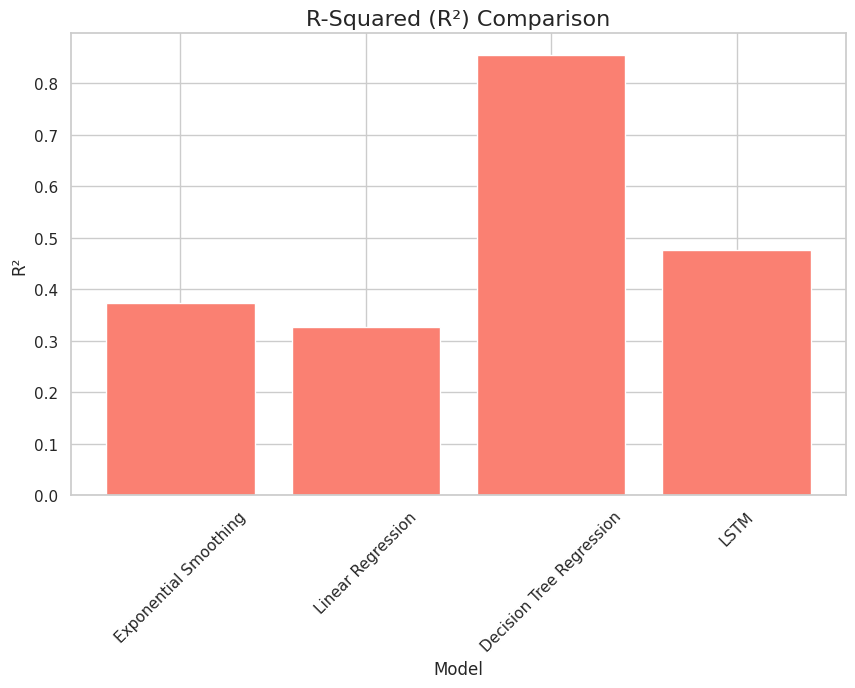

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(models, r2_values, color='salmon')
plt.title('R-Squared (R²) Comparison', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('R²', fontsize=12)
plt.xticks(rotation=45)
plt.show()

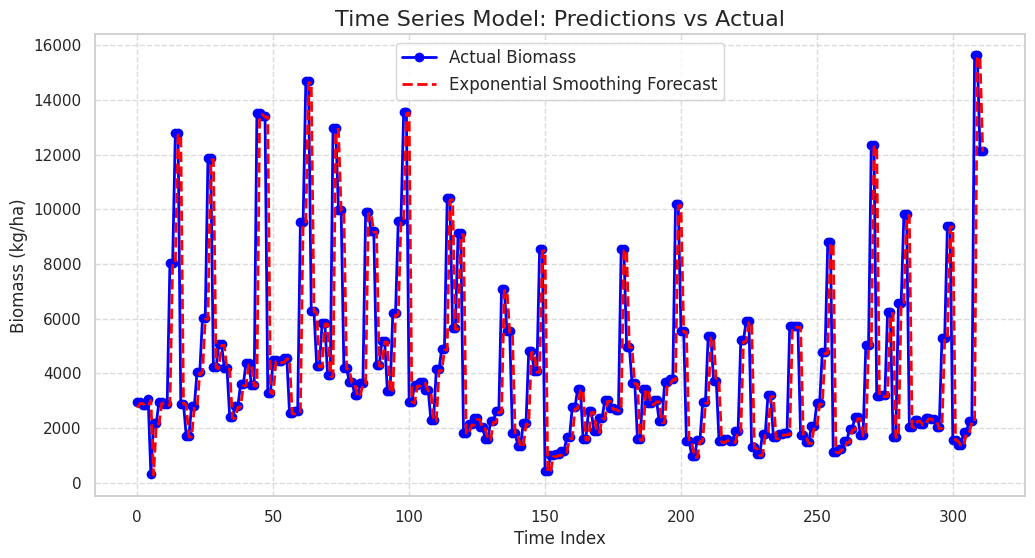

In [ ]:
if 'index' not in df1.columns:
    df1['index'] = range(len(df1))
plt.figure(figsize=(12, 6))
plt.plot(df1['index'], df1['Biomass'], label='Actual Biomass', color='blue', marker='o', linewidth=2)
plt.plot(df1['index'], time_series_forecast, label='Exponential Smoothing Forecast', color='red', linestyle='--', linewidth=2)
plt.title('Time Series Model: Predictions vs Actual', fontsize=16)
plt.xlabel('Time Index', fontsize=12)
plt.ylabel('Biomass (kg/ha)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

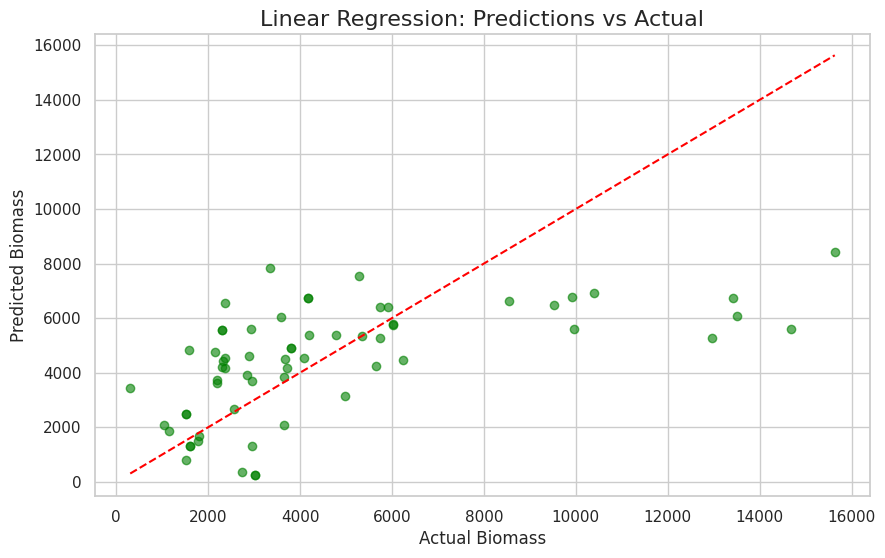

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, linear_predictions, color='green', alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')  # Perfect prediction line
plt.title('Linear Regression: Predictions vs Actual', fontsize=16)
plt.xlabel('Actual Biomass', fontsize=12)
plt.ylabel('Predicted Biomass', fontsize=12)
plt.show()

# Define variables

In [ ]:
rainfall = df['Rainfall']
temp_max = df['TEMP_MAX']
veg_index = df['NDVI']
esi_actual = df['Environmental Suitability Index']

# Normalize variables

In [ ]:
rainfall = (rainfall - rainfall.min()) / (rainfall.max() - rainfall.min())
temp_max = (temp_max - temp_max.min()) / (temp_max.max() - temp_max.min())
veg_index = (veg_index - veg_index.min()) / (veg_index.max() - veg_index.min())

# Objective function (Mean Squared Error)

In [ ]:
def objective_function(weights):
    predicted_esi = weights[0] * rainfall + weights[1] * temp_max + weights[2] * veg_index
    return mean_squared_error(esi_actual, predicted_esi)

# Genetic Algorithm (GA)

In [ ]:
def genetic_algorithm(pop_size, num_generations, bounds, mutation_rate):
    population = np.random.uniform(bounds[0][0], bounds[0][1], (pop_size, 3))
    best_solution = None
    best_fitness = float('inf')
    fitness_history = []

    for generation in range(num_generations):
        fitness = np.array([objective_function(ind) for ind in population])
        sorted_indices = np.argsort(fitness)
        population = population[sorted_indices]
        fitness = fitness[sorted_indices]

        if fitness[0] < best_fitness:
            best_fitness = fitness[0]
            best_solution = population[0]

        fitness_history.append(best_fitness)

        # Selection
        selected = population[:pop_size // 2]

        # Crossover
        offspring = []
        for i in range(0, len(selected), 2):
            if i + 1 < len(selected):
                crossover_point = np.random.randint(1, 3)
                child1 = np.hstack((selected[i][:crossover_point], selected[i + 1][crossover_point:]))
                child2 = np.hstack((selected[i + 1][:crossover_point], selected[i][crossover_point:]))
                offspring.extend([child1, child2])
        population = np.vstack((selected, offspring))

        # Mutation
        for individual in population:
            if np.random.rand() < mutation_rate:
                mutation_index = np.random.randint(0, 3)
                individual[mutation_index] = np.random.uniform(bounds[mutation_index][0], bounds[mutation_index][1])

    return best_solution, best_fitness, fitness_history

# Particle Swarm Optimization (PSO)

In [ ]:
def particle_swarm_optimization(pop_size, num_iterations, bounds):
    particles = np.random.uniform(bounds[0][0], bounds[0][1], (pop_size, 3))
    velocities = np.random.uniform(-0.1, 0.1, (pop_size, 3))
    personal_best = particles.copy()
    personal_best_scores = np.array([objective_function(p) for p in particles])
    global_best = particles[np.argmin(personal_best_scores)]
    global_best_score = np.min(personal_best_scores)
    fitness_history = []

    for iteration in range(num_iterations):
        for i in range(pop_size):
            fitness = objective_function(particles[i])
            if fitness < personal_best_scores[i]:
                personal_best[i] = particles[i]
                personal_best_scores[i] = fitness
            if fitness < global_best_score:
                global_best = particles[i]
                global_best_score = fitness

        fitness_history.append(global_best_score)
        inertia = 0.5
        cognitive = 1.5 * np.random.rand(pop_size, 3) * (personal_best - particles)
        social = 1.5 * np.random.rand(pop_size, 3) * (global_best - particles)
        velocities = inertia * velocities + cognitive + social
        particles = particles + velocities

    return global_best, global_best_score, fitness_history

# Execution details

In [ ]:
bounds = [(0, 1), (0, 1), (0, 1)]
pop_size = 30
num_generations = 50
num_iterations = 50


# Run GA

In [ ]:
ga_solution, ga_fitness, ga_history = genetic_algorithm(pop_size, num_generations, bounds, mutation_rate=0.1)


# Run PSO

In [ ]:
pso_solution, pso_fitness, pso_history = particle_swarm_optimization(pop_size, num_iterations, bounds)


# Results summary

In [ ]:
results = {
    'GA': {'Weights': ga_solution, 'Fitness': ga_fitness},
    'PSO': {'Weights': pso_solution, 'Fitness': pso_fitness}
}

# Predicted vs Actual ESI Plot

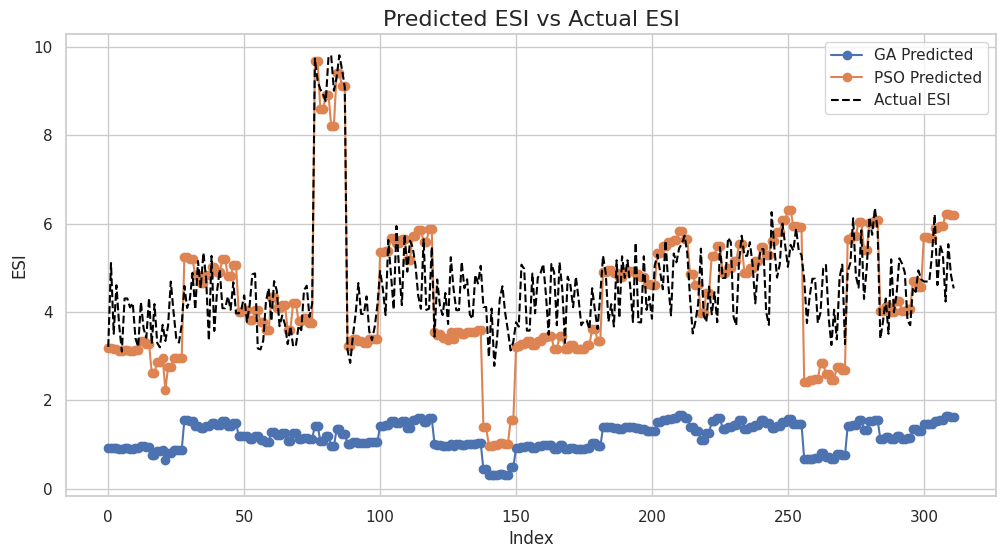

In [ ]:
plt.figure(figsize=(12, 6))
for method, result in results.items():
    predicted_esi = result['Weights'][0] * rainfall + result['Weights'][1] * temp_max + result['Weights'][2] * veg_index
    plt.plot(df.index, predicted_esi, label=f"{method} Predicted", marker='o')
plt.plot(df.index, esi_actual, label="Actual ESI", color='black', linestyle='--')
plt.title('Predicted ESI vs Actual ESI', fontsize=16)
plt.xlabel('Index', fontsize=12)
plt.ylabel('ESI', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

# Convergence Plot

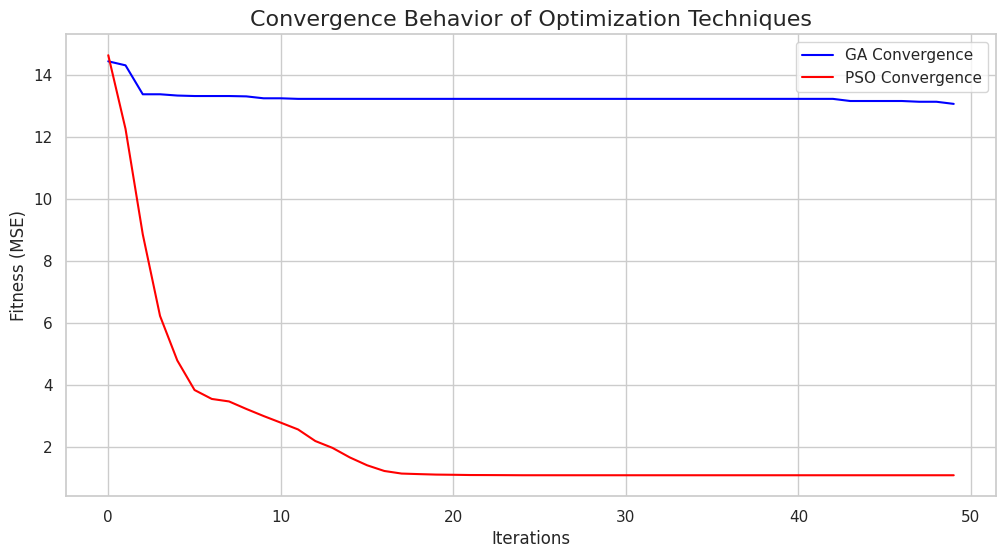

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(range(len(ga_history)), ga_history, label='GA Convergence', color='blue')
plt.plot(range(len(pso_history)), pso_history, label='PSO Convergence', color='red')
plt.title('Convergence Behavior of Optimization Techniques', fontsize=16)
plt.xlabel('Iterations', fontsize=12)
plt.ylabel('Fitness (MSE)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

# Results

In [ ]:
for method, result in results.items():
    print(f"{method} Results:")
    print(f"  Optimal Weights: {result['Weights']}")
    print(f"  Fitness (MSE): {result['Fitness']}\n")


GA Results:
  Optimal Weights: [0.96118931 0.99608807 0.97035342]
  Fitness (MSE): 13.075718610740465

PSO Results:
  Optimal Weights: [8.21801531 3.72931916 3.04660635]
  Fitness (MSE): 1.0815207834795204

